# Loading the libraries

In [1]:
!pip install evaluate
!pip uninstall -y torchvision

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.9 MB/s eta 0:00:00
Found existing installation: torchvision 0.26.0+cu128
Uninstalling torchvision-0.26.0+cu128:
  Successfully uninstalled torchvision-0.26.0+cu128


In [2]:
import evaluate
import os
import torch
import json
import random
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import torch.nn as nn
from google.colab import files
from torch.optim import AdamW
from transformers import AutoModelForSequenceClassification
from datasets import load_dataset, DatasetDict
from transformers import AutoTokenizer, get_scheduler, DataCollatorWithPadding
from torch.utils.data import DataLoader
from tqdm.auto import tqdm
from torch.nn.utils import clip_grad_norm_

# Configuration & Hyperparameters

In [3]:
save_path = "checkpoints/best_model"
os.makedirs(save_path, exist_ok=True)

In [4]:
def set_seed(seed: int):
    np.random.seed(seed)
    random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

In [5]:
seed = 42
set_seed(seed)
num_epochs = 3
max_length = 192
num_workers = 2
batch_size = 32
lr=2e-5
weight_decay=0.01
patience=2
delta=0.001
label_smoothing=0.1
best_f1 = 0.0
max_norm=1.0
mode="max"
checkpoint = 'roberta-base'
history = {
    "train_loss": [],
    "val_loss": [],
    "accuracy": [],
    "f1": []
    }

# Loading and exploring the data

In [6]:
raw_dataset = load_dataset(
    "fancyzhx/amazon_polarity",
    verification_mode="no_checks"
)

README.md:   0%|          | 0.00/6.81k [00:00<?, ?B/s]

amazon_polarity/train-00000-of-00004.par(…): reconstructing file:   0%|          |  0.00B /  260MB            

amazon_polarity/train-00000-of-00004.par(…): downloading bytes:           |  0.00B            

amazon_polarity/train-00001-of-00004.par(…): reconstructing file:   0%|          |  0.00B /  258MB            

amazon_polarity/train-00001-of-00004.par(…): downloading bytes:           |  0.00B            

...

amazon_polarity/train-00003-of-00004.par(…): downloading bytes:           |  0.00B            

amazon_polarity/test-00000-of-00001.parq(…): reconstructing file:   0%|          |  0.00B /  117MB            

amazon_polarity/test-00000-of-00001.parq(…): downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/3600000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/400000 [00:00<?, ? examples/s]

In [7]:
raw_dataset

DatasetDict({
    train: Dataset({
        features: ['label', 'title', 'content'],
        num_rows: 3600000
    })
    test: Dataset({
        features: ['label', 'title', 'content'],
        num_rows: 400000
    })
})

In [8]:
raw_dataset['train'][0]

{'label': 1,
 'title': 'Stuning even for the non-gamer',
 'content': 'This sound track was beautiful! It paints the senery in your mind so well I would recomend it even to people who hate vid. game music! I have played the game Chrono Cross but out of all of the games I have ever played it has the best music! It backs away from crude keyboarding and takes a fresher step with grate guitars and soulful orchestras. It would impress anyone who cares to listen! ^_^'}

In [9]:
raw_dataset['train'].column_names

['label', 'title', 'content']

In [10]:
raw_dataset['train'].features

{'label': ClassLabel(names=['negative', 'positive']),
 'title': Value('string'),
 'content': Value('string')}

# Preprocessing: Sampling & Splitting

In [11]:
sampled_dataset = DatasetDict({
    "train": raw_dataset["train"].shuffle(seed=seed).select(range(250000)),
    "test": raw_dataset["test"].shuffle(seed=seed).select(range(10000))
})

train_valid = sampled_dataset["train"].train_test_split(
    test_size=0.1,
    seed=seed
)

dataset = DatasetDict({
    "train": train_valid["train"],
    "validation": train_valid["test"],
    "test": sampled_dataset["test"]
})

# Export Test Set for Local Evaluation via evaluate.py in the Repo (Optional — commented out)

In [12]:
#dataset['test'].save_to_disk("amazon_dataset")
#!zip -r amazon_dataset.zip amazon_dataset
#files.download("amazon_dataset.zip")

# Label Distribution Check

In [13]:
train_labels = dataset["train"]["label"]
valid_labels = dataset["validation"]["label"]
test_labels = dataset["test"]["label"]

label_map = {1: 'positive', 0: 'negative'}

print('Train:')
print(pd.Series(train_labels).map(label_map).value_counts())
print('\nValidation:')
print(pd.Series(valid_labels).map(label_map).value_counts())
print('\nTest:')
print(pd.Series(test_labels).map(label_map).value_counts())

Train:
negative    113014
positive    111986
Name: count, dtype: int64

Validation:
negative    12558
positive    12442
Name: count, dtype: int64

Test:
positive    5042
negative    4958
Name: count, dtype: int64


# Tokenization

In [14]:
tokenizer = AutoTokenizer.from_pretrained(checkpoint)

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

In [15]:
def tokenize_function(example):
  return tokenizer(example['title'], example['content'], truncation=True, max_length=max_length)

In [16]:
tokenized_dataset = dataset.map(tokenize_function, batched=True)
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

Map:   0%|          | 0/225000 [00:00<?, ? examples/s]

Map:   0%|          | 0/25000 [00:00<?, ? examples/s]

Map:   0%|          | 0/10000 [00:00<?, ? examples/s]

In [17]:
tokenized_dataset['train'].column_names

['label', 'title', 'content', 'input_ids', 'attention_mask']

In [18]:
tokenized_dataset = tokenized_dataset.remove_columns(['title', 'content'])
tokenized_dataset = tokenized_dataset.rename_column("label", "labels")
tokenized_dataset.set_format("torch")
tokenized_dataset["train"].column_names

['labels', 'input_ids', 'attention_mask']

In [19]:
example = tokenized_dataset["train"][0]

for key, value in example.items():
    print(key)
    print(value)
    print()

labels
tensor(0)

input_ids
tensor([    0, 38145,  2650,  3344,     2,     2,   713, 19834,    21,  1099,
            4,    20,  3686,     8,     5,  3344,     9,  3528,    21,    45,
         2375,     4, 36420,   101,    24,    21,    70,  5629,   561,    23,
            5,    94,  2289,     4,    20,   129,   205,  2214,    16, 11297,
          226,  2611, 28545,    18,  6921, 20081,  9103,     4,  4657, 21953,
        10208,  1411,    66,     7, 15730,    19,    39,    80,  7428,     6,
          455,     9,  2342,  5865,  3686,     4,  7124,    15,    42,  7522,
           50, 30180,    24,    31,    10,  1441,     4, 34675,   110,  1932,
           15,  1918,   523,    50,   402,  1493,     2])

attention_mask
tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1,

# Sequence Length Analysis

In [20]:
titles = list(dataset["train"]["title"])
contents = list(dataset["train"]["content"])

tokenized_lengths = tokenizer(titles, contents)
lengths = [len(ids) for ids in tokenized_lengths["input_ids"]]

print("Average:", np.mean(lengths))
print("Max:", np.max(lengths))
print("95th Percentile:", np.percentile(lengths, 95))

Average: 101.63154666666667
Max: 400
95th Percentile: 205.0


# DataLoaders

In [21]:
def create_dataloaders (tokenized_dataset, data_collator, batch_size):

  train_loader = DataLoader(
    tokenized_dataset['train'],
    shuffle=True,
    batch_size=batch_size,
    collate_fn=data_collator,
    num_workers=num_workers,
    pin_memory=True,
    persistent_workers=True
    )

  validation_loader = DataLoader(
    tokenized_dataset['validation'],
    shuffle=False,
    batch_size=batch_size,
    collate_fn=data_collator,
    num_workers=num_workers,
    pin_memory=True,
    persistent_workers=True
    )

  return train_loader, validation_loader

In [22]:
train_dataloader, validation_dataloader = create_dataloaders(
    tokenized_dataset,
    data_collator,
    batch_size=batch_size
    )

In [23]:
for batch in train_dataloader:
  break
{k: v.shape for k, v in batch.items()}

{'labels': torch.Size([32]),
 'input_ids': torch.Size([32, 192]),
 'attention_mask': torch.Size([32, 192])}

# Model Setup

In [24]:
model = AutoModelForSequenceClassification.from_pretrained(
    checkpoint,
    num_labels=2,
    hidden_dropout_prob=0.1,
    attention_probs_dropout_prob=0.1
)

model.safetensors: reconstructing file:   0%|          |  0.00B /  499MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.dense.weight       | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
classifier.out_proj.bias   | MISSING    | 
classifier.out_proj.weight | MISSING    | 
classifier.dense.weight    | MISSING    | 
classifier.dense.bias      | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


# Layer Freezing

In [25]:
for param in model.roberta.embeddings.parameters():
    param.requires_grad = False

for layer in model.roberta.encoder.layer[:4]:
    for param in layer.parameters():
        param.requires_grad = False

In [26]:
print(model)

RobertaForSequenceClassification(
  (roberta): RobertaModel(
    (embeddings): RobertaEmbeddings(
      (word_embeddings): Embedding(50265, 768, padding_idx=1)
      (token_type_embeddings): Embedding(1, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
      (position_embeddings): Embedding(514, 768, padding_idx=1)
    )
    (encoder): RobertaEncoder(
      (layer): ModuleList(
        (0-11): 12 x RobertaLayer(
          (attention): RobertaAttention(
            (self): RobertaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): RobertaSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
             

# Sanity Check: Forward Pass on One Batch

In [27]:
outputs = model(**batch)
print(outputs.loss, outputs.logits.shape)

tensor(0.6986, grad_fn=<NllLossBackward0>) torch.Size([32, 2])


# Device Setup

In [28]:
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
model.to(device)
device

device(type='cuda')

# Optimizer & Learning Rate Scheduler

In [29]:
no_decay = ["bias", "LayerNorm.weight"]
optimizer_grouped_parameters = [
    {
        "params": [p for n, p in model.named_parameters() if p.requires_grad and not any(nd in n for nd in no_decay)],
        "weight_decay": weight_decay,
    },
    {
        "params": [p for n, p in model.named_parameters() if p.requires_grad and any(nd in n for nd in no_decay)],
        "weight_decay": 0.0,
    },
]
optimizer = AdamW(optimizer_grouped_parameters, lr=lr, fused=True)

In [30]:
num_steps = num_epochs * len(train_dataloader)
lr_scheduler = get_scheduler('cosine', optimizer=optimizer, num_warmup_steps= int(0.1 * num_steps), num_training_steps=num_steps)
print(num_steps)

21096


# Early Stopping Class

In [31]:
class EarlyStopping:
    def __init__(self, patience=3, delta=0.0, mode="max", verbose=True):
        self.patience = patience
        self.verbose = verbose
        self.mode = mode
        self.counter = 0
        self.best_score = None
        self.should_stop = False
        self.delta = delta

        if mode == "max":
          self.best_score = float("-inf")
        else:
          self.best_score = float("inf")

    def step(self, current_score):
      if self.mode == "max":
        improved = current_score > (self.best_score + self.delta)
      else:
        improved = current_score < (self.best_score - self.delta)

      if improved:
        self.best_score = current_score
        self.counter = 0
        if self.verbose:
          print(f"New Best Score: {self.best_score:.4f}")

      else:
        self.counter += 1
        if self.verbose:
          print(f"No Improvement! Early Stopping Counter Triggered. {self.counter}/{self.patience}")
        if self.counter >= self.patience:
          self.should_stop = True

      return self.should_stop

In [32]:
early_stopping = EarlyStopping(
    patience=patience,
    delta=delta,
    mode=mode
)

# Loss Function & Evaluation Metrics

In [33]:
scaler = torch.amp.GradScaler("cuda")
loss_fct = nn.CrossEntropyLoss(label_smoothing=label_smoothing)

accuracy_metric = evaluate.load("accuracy")
f1_metric = evaluate.load("f1")

# Training & Validation Loop

In [34]:
for epoch in range (num_epochs):
  model.train()
  running_train_loss = 0

  progress_bar = tqdm(
        train_dataloader,
        desc=f"Epoch {epoch+1}/{num_epochs}"
    )

  for batch in progress_bar:
    batch = {k: v.to(device) for k, v in batch.items()}

    with torch.amp.autocast("cuda"):
      outputs = model(**batch)
      loss = loss_fct(outputs.logits, batch["labels"])

    running_train_loss += loss.item()
    scaler.scale(loss).backward()
    scaler.unscale_(optimizer)
    clip_grad_norm_(model.parameters(), max_norm=max_norm)
    scaler.step(optimizer)
    scaler.update()
    lr_scheduler.step()
    optimizer.zero_grad(set_to_none=True)
    progress_bar.set_postfix(loss=f"{loss.item():.4f}")

  train_loss = running_train_loss / len(train_dataloader)

  model.eval()
  running_val_loss = 0

  with torch.no_grad():
    for batch in validation_dataloader:
      batch = {k: v.to(device) for k, v in batch.items()}

      with torch.amp.autocast("cuda"):
        outputs = model(**batch)
        loss = loss_fct(outputs.logits, batch["labels"])

      running_val_loss += loss.item()

      logits = outputs.logits
      predictions = torch.argmax(logits, dim=-1)

      accuracy_metric.add_batch(
      predictions=predictions,
      references=batch["labels"]
      )
      f1_metric.add_batch(
      predictions=predictions,
      references=batch["labels"]
      )

  val_loss = running_val_loss / len(validation_dataloader)

  accuracy = accuracy_metric.compute()
  f1 = f1_metric.compute(average="binary")
  current_f1 = f1['f1']

  if current_f1 > best_f1:
    best_f1 = f1['f1']
    model.save_pretrained(save_path)
    tokenizer.save_pretrained(save_path)
    print(f"New Best Model Saved! F1 = {best_f1:.4f}")


  history["train_loss"].append(train_loss)
  history["val_loss"].append(val_loss)
  history["accuracy"].append(accuracy["accuracy"])
  history["f1"].append(f1["f1"])


  print(f"Epoch {epoch + 1}/{num_epochs}")
  print(f"Train Loss: {train_loss:.4f}")
  print(f"Validation Loss: {val_loss:.4f}")
  print(f"Validation Accuracy: {accuracy['accuracy']:.4f}")
  print(f"Validation F1 Score: {f1['f1']:.4f}")

  if early_stopping.step(current_f1):
    break

Epoch 1/3:   0%|          | 0/7032 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

New Best Model Saved! F1 = 0.9645
Epoch 1/3
Train Loss: 0.2937
Validation Loss: 0.2646
Validation Accuracy: 0.9647
Validation F1 Score: 0.9645
New Best Score: 0.9645


Epoch 2/3:   0%|          | 0/7032 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

New Best Model Saved! F1 = 0.9674
Epoch 2/3
Train Loss: 0.2549
Validation Loss: 0.2610
Validation Accuracy: 0.9674
Validation F1 Score: 0.9674
New Best Score: 0.9674


Epoch 3/3:   0%|          | 0/7032 [00:00<?, ?it/s]

Epoch 3/3
Train Loss: 0.2393
Validation Loss: 0.2654
Validation Accuracy: 0.9672
Validation F1 Score: 0.9671
No Improvement! Early Stopping Counter Triggered. 1/2


# Load Best Saved Model

In [35]:
model = AutoModelForSequenceClassification.from_pretrained(save_path).to(device)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

# Plotting: Loss / Accuracy / F1 Curves

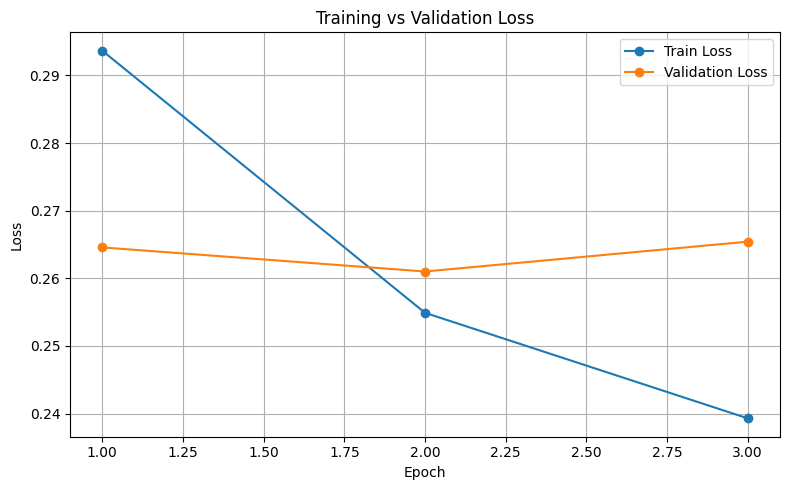

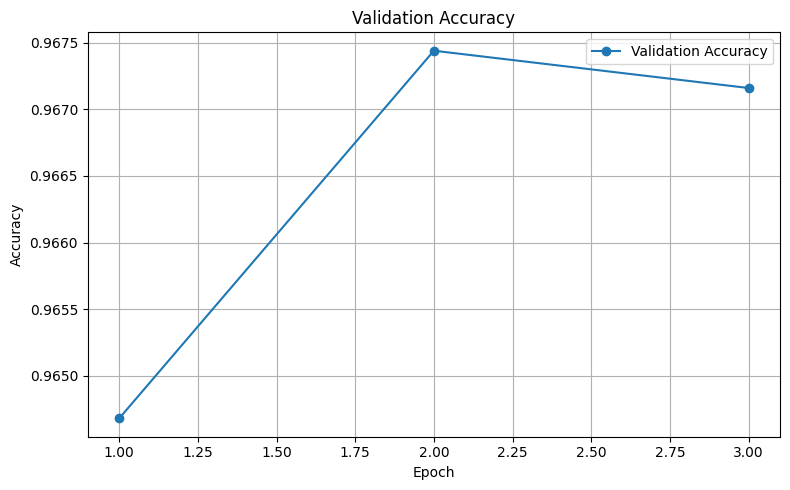

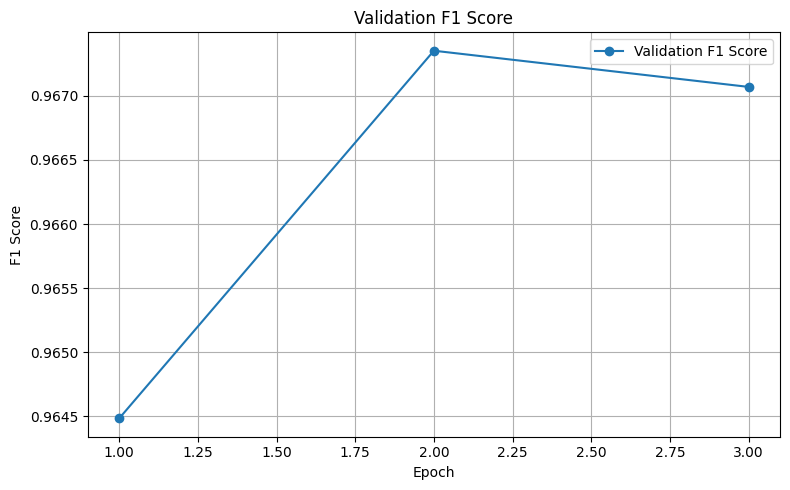

Graphs saved successfully!


In [36]:
os.makedirs("Results", exist_ok=True)
epochs = range(1, len(history["train_loss"]) + 1)

# ===========================
# Loss Curve
# ===========================

plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    history["train_loss"],
    marker="o",
    label="Train Loss"
)

plt.plot(
    epochs,
    history["val_loss"],
    marker="o",
    label="Validation Loss"
)

plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.legend()

plt.tight_layout()

plt.savefig("Results/loss_curve.png", dpi=300)

plt.show()

# ===========================
# Accuracy Curve
# ===========================
plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    history["accuracy"],
    marker="o",
    label="Validation Accuracy"
)

plt.title("Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.grid(True)
plt.legend()

plt.tight_layout()

plt.savefig("Results/accuracy_curve.png", dpi=300)

plt.show()

# ===========================
# F1 Curve
# ===========================
plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    history["f1"],
    marker="o",
    label="Validation F1 Score"
)

plt.title("Validation F1 Score")
plt.xlabel("Epoch")
plt.ylabel("F1 Score")
plt.grid(True)
plt.legend()

plt.tight_layout()

plt.savefig("Results/f1_curve.png", dpi=300)

plt.show()

print("Graphs saved successfully!")

# Export / Download (Optional — commented out)

In [37]:
!zip -r best_model.zip checkpoints/best_model
files.download("best_model.zip")

  adding: checkpoints/best_model/ (stored 0%)
  adding: checkpoints/best_model/tokenizer.json (deflated 82%)
  adding: checkpoints/best_model/config.json (deflated 51%)
  adding: checkpoints/best_model/model.safetensors (deflated 25%)
  adding: checkpoints/best_model/tokenizer_config.json (deflated 51%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [38]:
with open("history.json", "w") as f:
    json.dump(history, f)
files.download("history.json")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>